In [1]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, PowerTransformer
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import joblib

In [2]:
# Load dataset
df = pd.read_csv("data.csv")

# Check for missing values
print("Columns:", df.columns)
print("Missing values:\n", df.isnull().sum())

# Define features and targets
X = df[['SAl', 'SAz', 'DNI', 'DHI', 'GHI', 'LA']].values
y = df[['Ev', 'rUDI']].values

# Check the range of inputs and outputs
print("\nInput features' ranges:")
print("SAl (min, max):", X[:, 0].min(), X[:, 0].max())
print("SAz (min, max):", X[:, 1].min(), X[:, 1].max())
print("DNI (min, max):", X[:, 2].min(), X[:, 2].max())
print("DHI (min, max):", X[:, 3].min(), X[:, 3].max())
print("GHI (min, max):", X[:, 4].min(), X[:, 4].max())
print("LA (min, max):", X[:, 5].min(), X[:, 5].max())
print("\nTargets' ranges:")
print("Ev (min, max):", y[:, 0].min(), y[:, 0].max())
print("rUDI (min, max):", y[:, 1].min(), y[:, 1].max())

Columns: Index(['SAl', 'SAz', 'DNI', 'DHI', 'GHI', 'LA', 'Ev', 'rUDI'], dtype='object')
Missing values:
 SAl     0
SAz     0
DNI     0
DHI     0
GHI     0
LA      0
Ev      0
rUDI    0
dtype: int64

Input features' ranges:
SAl (min, max): 8.22 81.45
SAz (min, max): 83.75 277.47
DNI (min, max): 0.0 100243.0
DHI (min, max): 1546.0 49297.0
GHI (min, max): 1566.0 105141.0
LA (min, max): -40.0 60.0

Targets' ranges:
Ev (min, max): 34.0 41284.0
rUDI (min, max): 0.0 0.87


In [3]:
# Split dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


# Normalize features and targets
scaler_X = StandardScaler()
X_train_scaled = scaler_X.fit_transform(X_train)
X_test_scaled = scaler_X.transform(X_test)

joblib.dump(scaler_X, 'scaler_input_daylight.pkl')

scaler_y = StandardScaler()
y_train_scaled = scaler_y.fit_transform(y_train)
y_test_scaled = scaler_y.transform(y_test)

joblib.dump(scaler_y, 'scaler_output_daylight.pkl')

# Check the scale of features and targets
print("\nScaled input features' ranges:")
print("LA (min, max):", X_train_scaled[:, 0].min(), X_train_scaled[:, 0].max())
print("SAl (min, max):", X_train_scaled[:, 1].min(), X_train_scaled[:, 1].max())
print("SAz (min, max):", X_train_scaled[:, 2].min(), X_train_scaled[:, 2].max())
print("DNI (min, max):", X_train_scaled[:, 3].min(), X_train_scaled[:, 3].max())
print("DHI (min, max):", X_train_scaled[:, 4].min(), X_train_scaled[:, 4].max())
print("GHI (min, max):", X_train_scaled[:, 5].min(), X_train_scaled[:, 5].max())
print("\nScaled targets' ranges:")
print("Ev (min, max):", y_train_scaled[:, 0].min(), y_train_scaled[:, 0].max())
print("rUDI (min, max):", y_train_scaled[:, 1].min(), y_train_scaled[:, 1].max())


Scaled input features' ranges:
LA (min, max): -1.9629000846711189 2.21438330300891
SAl (min, max): -1.734944423922231 1.6855945715459073
SAz (min, max): -3.2052611347850424 1.566392185410765
DNI (min, max): -2.349812706903593 4.703919465520932
DHI (min, max): -2.4039393125695505 1.6880406770829355
GHI (min, max): -1.7289038081617178 1.7240819506242353

Scaled targets' ranges:
Ev (min, max): -0.6538279612238143 3.5436260343356905
rUDI (min, max): -2.3527757860098313 2.106176175974211


In [4]:
# Build model
model = keras.Sequential([
    layers.Dense(512, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    layers.BatchNormalization(),
    layers.Dropout(0.1),

    layers.Dense(256, activation='relu', kernel_regularizer=regularizers.l2(0.01)),
    layers.BatchNormalization(),

    layers.Dense(64, activation='relu', kernel_regularizer=regularizers.l2(0.01)),
    layers.BatchNormalization(),

    layers.Dense(2, activation='linear')  # Output layer for EV and RUDI
])

optimizer = keras.optimizers.Adam(
    learning_rate=keras.optimizers.schedules.ExponentialDecay(
        initial_learning_rate=0.005,
        decay_steps=50,
        decay_rate=0.9
    )
)

model.compile(optimizer=optimizer, loss='mse', metrics=['mae'])
#model.summary()

# Training
early_stopping = keras.callbacks.EarlyStopping(patience=20, restore_best_weights=True)

history = model.fit(
    X_train_scaled, y_train_scaled,
    epochs=300,
    batch_size=128,
    validation_data=(X_test_scaled, y_test_scaled),
    callbacks=[early_stopping],
    verbose=1
)

joblib.dump(model, 'Daylight_Model.pkl')  # save as a .pkl file

c:\Users\fatem\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/300
21/21 ━━━━━━━━━━━━━━━━━━━━ 4s 30ms/step - loss: 6.1613 - mae: 0.8984 - val_loss: 4.5262 - val_mae: 0.6099
Epoch 2/300
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 3.7763 - mae: 0.3642 - val_loss: 3.2842 - val_mae: 0.6988
Epoch 3/300
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 2.3797 - mae: 0.3262 - val_loss: 2.4264 - val_mae: 0.7077
Epoch 4/300
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 1.5446 - mae: 0.3237 - val_loss: 1.9957 - val_mae: 0.7134
Epoch 5/300
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 1.0621 - mae: 0.3233 - val_loss: 1.6813 - val_mae: 0.7313
Epoch 6/300
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.8432 - mae: 0.3441 - val_loss: 1.5245 - val_mae: 0.7044
Epoch 7/300
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.6676 - mae: 0.3151 - val_loss: 1.3733 - val_mae: 0.6509
Epoch 8/300
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.5736 - mae: 0.3263 - val_loss: 1.3253 - val_mae: 0.6610
Epoch 9/300
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - lo

['Daylight_Model.pkl']

In [5]:
# Predict and inverse scaling
y_pred_scaled = model.predict(X_test_scaled)
y_pred = scaler_y.inverse_transform(y_pred_scaled)  # Back to original scale

y_pred_scaled_train = model.predict(X_train_scaled)
y_pred_train = scaler_y.inverse_transform(y_pred_scaled_train)  # Back to original scale

# Compare predictions vs actual (first 5 samples)
print("\nSample Predictions vs Actual:")
for i in range(5):
    print(f"Sample {i+1}: Predicted Ev={y_pred[i, 0]:.2f}, Actual Ev={y_test[i, 0]:.2f} | Predicted rUDI={y_pred[i, 1]:.2f}, Actual rUDI={y_test[i, 1]:.2f}")

# Metrics
train_loss = history.history['loss']        # Training MSE loss per epoch
train_mae = history.history['mae']         # Training MAE per epoch
val_loss = history.history['val_loss']     # Validation MSE loss per epoch
val_mae = history.history['val_mae']       # Validation MAE per epoch

# Print final epoch metrics
print(f"\nFinal Training Loss (MSE): {train_loss[-1]:.4f}")
print(f"Final Training MAE: {train_mae[-1]:.4f}")
print(f"Final Validation Loss (MSE): {val_loss[-1]:.4f}")
print(f"Final Validation MAE: {val_mae[-1]:.4f}")

# Original scale metrics
r2_model_train = r2_score(y_train, y_pred_train)
r2_model_train_ev = r2_score(y_train[:, 0], y_pred_train[:, 0])
r2_model_train_rudi = r2_score(y_train[:, 1], y_pred_train[:, 1])
r2_model = r2_score(y_test, y_pred)
r2_ev = r2_score(y_test[:, 0], y_pred[:, 0])
r2_rudi = r2_score(y_test[:, 1], y_pred[:, 1])
mae_model= mean_absolute_error(y_test, y_pred)
mae_ev = mean_absolute_error(y_test[:, 0], y_pred[:, 0])
mae_rudi = mean_absolute_error(y_test[:, 1], y_pred[:, 1])
mse_model = mean_squared_error(y_test, y_pred)
mse_ev = mean_squared_error(y_test[:, 0], y_pred[:, 0])
mse_rudi = mean_squared_error(y_test[:, 1], y_pred[:, 1])

print(f"\nR² for model_train: {r2_model_train:.3f}")
print(f"R² for model_train_ev: {r2_model_train_ev:.3f}")
print(f"R² for model_train_rudi: {r2_model_train_rudi:.3f}")
print(f"R² for model: {r2_model:.3f}")
print(f"R² for Ev: {r2_ev:.3f}")
print(f"R² for rUDI: {r2_rudi:.3f}")
print(f"\nMAE for model: {mae_model:.3f}")
print(f"MAE for Ev: {mae_ev:.2f}")
print(f"MAE for rUDI: {mae_rudi:.4f}")
print(f"\nMSE for model: {mse_model:.3f}")
print(f"MSE for Ev: {mse_ev:.2f}")
print(f"MSE for rUDI: {mse_rudi:.4f}")

21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step

Sample Predictions vs Actual:
Sample 1: Predicted Ev=3282.28, Actual Ev=3927.00 | Predicted rUDI=0.52, Actual rUDI=0.53
Sample 2: Predicted Ev=3307.71, Actual Ev=2631.00 | Predicted rUDI=0.72, Actual rUDI=0.73
Sample 3: Predicted Ev=2521.85, Actual Ev=2779.00 | Predicted rUDI=0.69, Actual rUDI=0.68
Sample 4: Predicted Ev=2548.81, Actual Ev=2814.00 | Predicted rUDI=0.44, Actual rUDI=0.46
Sample 5: Predicted Ev=2993.09, Actual Ev=3016.00 | Predicted rUDI=0.62, Actual rUDI=0.63

Final Training Loss (MSE): 0.0962
Final Training MAE: 0.1545
Final Validation Loss (MSE): 0.1407
Final Validation MAE: 0.1538

R² for model_train: 0.935
R² for model_train_ev: 0.885
R² for model_train_rudi: 0.985
R² for model: 0.885
R² for Ev: 0.794
R² for rUDI: 0.975

MAE for model: 993.805
MAE for Ev: 1987.59
MAE for rUDI: 0.0210

MSE for model: 10197884.422
MSE for Ev: 20395768.84
MSE for rUDI: 0.0009


In [12]:
import pandas as pd

y_pred_scaled = model.predict(X_test_scaled)
y_pred = scaler_y.inverse_transform(y_pred_scaled)

# Create DataFrames
df_test = pd.DataFrame({
    'Actual_Ev': y_test[:, 0],
    'Predicted_Ev': y_pred[:, 0],
    'Actual_rUDI': y_test[:, 1],
    'Predicted_rUDI': y_pred[:, 1]
})


# Save to CSV
df_test.to_csv('test_predictions.csv', index=False)


21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step


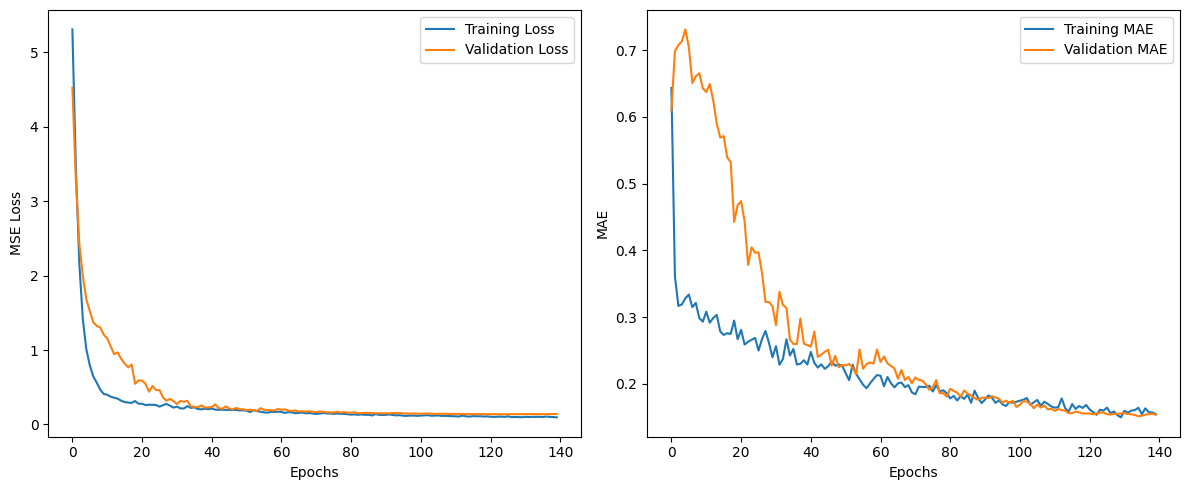

In [7]:
# Plot training curves
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('MSE Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['mae'], label='Training MAE')
plt.plot(history.history['val_mae'], label='Validation MAE')
plt.xlabel('Epochs')
plt.ylabel('MAE')
plt.legend()
plt.tight_layout()
plt.show()

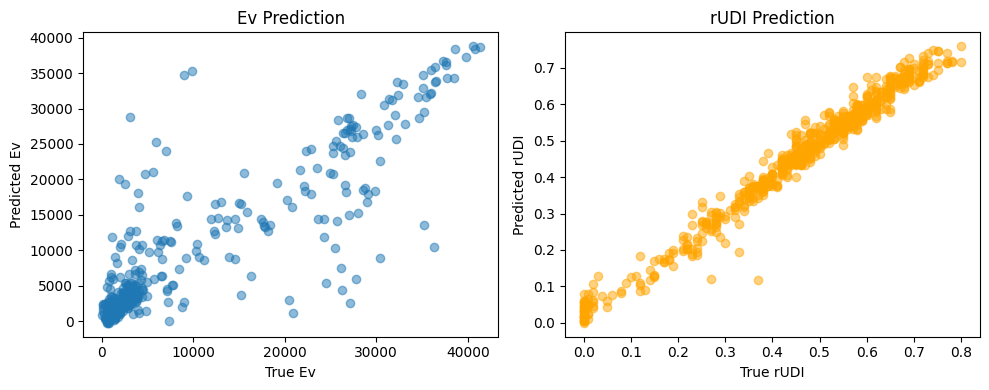

In [8]:
# Scatter plot of predictions vs true values
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.scatter(y_test[:, 0], y_pred[:, 0], alpha=0.5)
plt.xlabel('True Ev')
plt.ylabel('Predicted Ev')
plt.title('Ev Prediction')

plt.subplot(1, 2, 2)
plt.scatter(y_test[:, 1], y_pred[:, 1], alpha=0.5, color='orange')
plt.xlabel('True rUDI')
plt.ylabel('Predicted rUDI')
plt.title('rUDI Prediction')
plt.tight_layout()
plt.show()

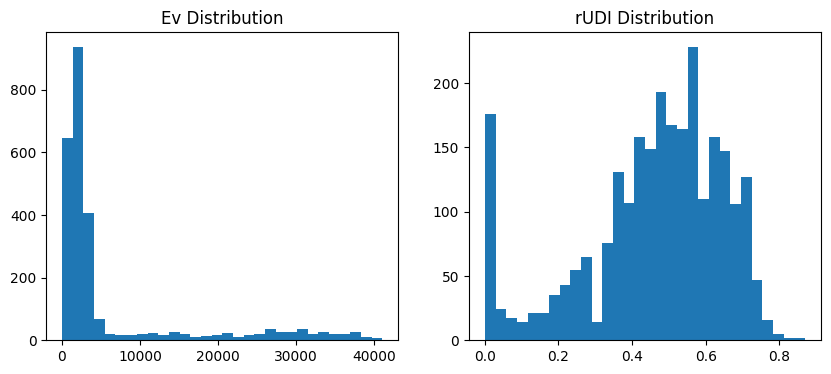

In [9]:
# Check target distributions
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.hist(y_train[:, 0], bins=30)  # Ev distribution
plt.title('Ev Distribution')

plt.subplot(1, 2, 2)
plt.hist(y_train[:, 1], bins=30)  # rUDI distribution
plt.title('rUDI Distribution')
plt.show()